In [6]:
!pip install datasets -q

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete!")

Setup complete!


### Step 1: Load and Subset the Data
We will use `load_dataset("stanfordnlp/imdb")`. To save time and memory, we will only use the first 5,000 rows for training and 1,000 for testing.

In [7]:
# Load the dataset
dataset = load_dataset("stanfordnlp/imdb")

# TODO: Extract the text (features) and labels from the train and test splits.
# Subset them: take the first 5000 from train, and first 1000 from test.
# the imdb dataset has continous 0s then continous 1s, hence,
# we shuffle the subset to ensure an even distribution of labels, making learning faster/viable.
train_subset = dataset['train'].shuffle(seed=42).select(range(5000)) # .shuffle and .select are 'lazy', i.e. they only perform their operation as you read the information one by one later on

X_train = train_subset['text']
y_train = train_subset['label']

test_subset = dataset['test'].shuffle(seed=42).select(range(1000))

X_test = test_subset['text']
y_test = test_subset['label']

print(f"Loaded {len(X_train)} training reviews and {len(X_test)} testing reviews.")

Loaded 5000 training reviews and 1000 testing reviews.


### Step 2: Word to Math (TF-IDF)
Machines can't read English. We need to convert these text reviews into numbers using a `TfidfVectorizer`.

In [8]:
# TODO: Initialize the TfidfVectorizer. (Optional: limit max_features to 5000 to keep it fast)
vectorizer = TfidfVectorizer(max_features=5000)

# TODO: fit_transform the training data, and just transform the testing data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Data vectorized!")

Data vectorized!


### Step 3: Train the Model
Time to train the Classical ML algorithm: Logistic Regression.

In [9]:
# TODO: Initialize LogisticRegression and fit it to your vectorized training data
model = LogisticRegression(max_iter=1000)
# Fit the model: model.fit(...)
model.fit(X_train_vec, y_train)

print("Model trained!")

Model trained!


### Step 4: Evaluate
How good is your AI movie critic? Let's predict on the test set and calculate the metrics.

Accuracy: 0.8460
F1 Score: 0.8454

Confusion Matrix:
[[425  87]
 [ 67 421]]


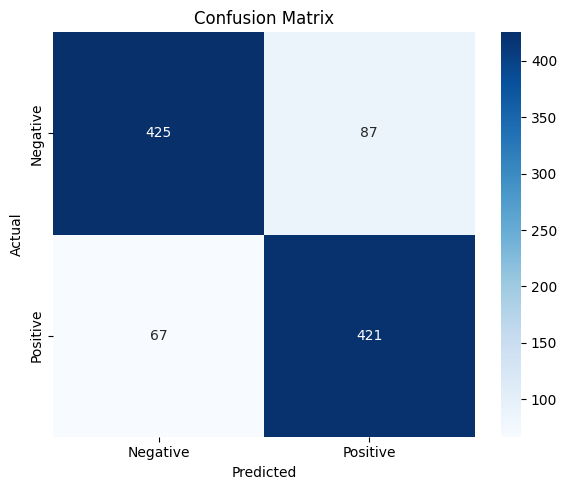

In [10]:
# TODO: Predict on X_test_vec
y_pred = model.predict(X_test_vec)

# TODO: Calculate and print the Accuracy and F1 Score
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

# TODO: Generate the confusion matrix and print it (Bonus points if you plot it using seaborn heatmap!)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()